In [1]:
import pandas as pd
from modules.v1.neural_network import NeuralNetworkTrainable as nn

In [2]:
data_file_path = "./data/MNIST_CSV/mnist_train.csv"

df = pd.read_csv(data_file_path)

df.head(20)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.describe()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
count,59999.000000,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,...,59999.000000,59999.000000,59999.000000,59999.000000,59999.000000,59999.000000,59999.0,59999.0,59999.0,59999.0
mean,4.453924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200437,0.088868,0.045634,0.019284,0.015117,0.002000,0.0,0.0,0.0,0.0
std,2.889294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042522,3.956222,2.839868,1.686784,1.678297,0.346603,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [4]:
import numpy as np

Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:] / 255

In [5]:
Y.max()

5    9
dtype: int64

In [6]:
x.max()

0        0.000000
0.1      0.000000
0.2      0.000000
0.3      0.000000
0.4      0.000000
           ...   
0.613    0.243137
0.614    0.000000
0.615    0.000000
0.616    0.000000
0.617    0.000000
Length: 784, dtype: float64

In [7]:
df.shape

(59999, 785)

In [8]:
Y.shape

(59999, 1)

In [9]:
x.shape

(59999, 784)

In [10]:
x = x.to_numpy()
Y = Y.to_numpy()
nb_classes = 10
Y.shape
one_hot_targets = np.eye(nb_classes)[Y]

In [11]:
one_hot_targets = one_hot_targets.reshape(59999, 10)

In [12]:
x.shape, one_hot_targets.shape

((59999, 784), (59999, 10))

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


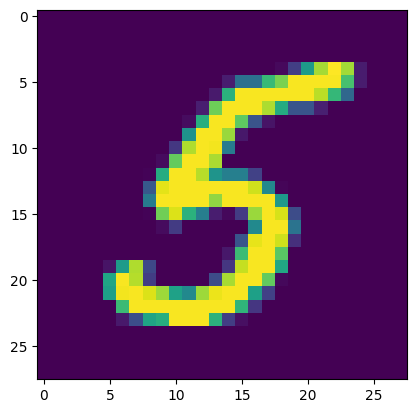

In [13]:
import matplotlib.pyplot as plt
import numpy as np

random_choice = np.random.randint(0, 5999)
print(one_hot_targets[random_choice])
plt.imshow(x[random_choice].reshape(28, 28))
plt.show()

## Try the Model

In [14]:
from modules.v1.sequential_framework import SeqFrameworkTrainable
from modules.v1.neural_network import NeuralNetworkTrainable as nn

In [15]:
model = SeqFrameworkTrainable()

model.add(nn(784, 128, "sigmoid"))
model.add(nn(128, 10, "sigmoid"))

model.train(x=x, Y=one_hot_targets, lr=0.005, epochs=600, batch_size=16)

epoch 0 loss: 0.15115426014865796
epoch 1 loss: 0.14923965013179344
epoch 2 loss: 0.14705074319081407
epoch 3 loss: 0.1448260175562679
epoch 4 loss: 0.14310207800161126
epoch 5 loss: 0.14107882239336655
epoch 6 loss: 0.13911407895233766
epoch 7 loss: 0.13710917265319136
epoch 8 loss: 0.1353822558524264
epoch 9 loss: 0.13349803857855602
epoch 10 loss: 0.13177667500189028
epoch 11 loss: 0.1297677941392264
epoch 12 loss: 0.12780789638432566
epoch 13 loss: 0.1262692530190377
epoch 14 loss: 0.12499062871760384
epoch 15 loss: 0.12298662208215164
epoch 16 loss: 0.12131281209875261
epoch 17 loss: 0.11974779943912181
epoch 18 loss: 0.11801275257654645
epoch 19 loss: 0.11663893499460036
epoch 20 loss: 0.11498856304183215
epoch 21 loss: 0.11346639982372451
epoch 22 loss: 0.11204761860140906
epoch 23 loss: 0.1106693582112559
epoch 24 loss: 0.10936110083537906
epoch 25 loss: 0.10798697228696157
epoch 26 loss: 0.10656388329687771
epoch 27 loss: 0.10537316639787
epoch 28 loss: 0.10392273581838458
epo

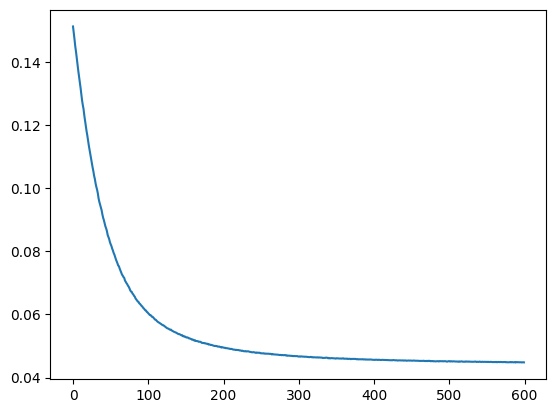

In [16]:
l = model.loss_hist
t = [i for i in range(len(l))]

plt.plot(t, l)
plt.show()

In [17]:
random_choice = np.random.randint(0, 5999)

y_pred = model.predict(x[random_choice])

print(y_pred)
print(one_hot_targets[random_choice])
print("\nround version\n")
print(np.round(y_pred))
print(one_hot_targets[random_choice])

[[0.14222148 0.11452097 0.10570801 0.10973932 0.14292179 0.10481476
  0.11030091 0.09745764 0.13244954 0.11945514]]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

round version

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [18]:
from pympler import asizeof

b_size = asizeof.asizeof(model.get_models_config)
kb_size = b_size / 1024
mb_size = kb_size / 1024
print(f"size in byte: {b_size} | size in kb: {kb_size} | size in mb: {mb_size}")

size in byte: 816200 | size in kb: 797.0703125 | size in mb: 0.7783889770507812


In [19]:
b_size = asizeof.asizeof(model)
kb_size = b_size / 1024
mb_size = kb_size / 1024
print(f"size in byte: {b_size} | size in kb: {kb_size} | size in mb: {mb_size}")

size in byte: 377167336 | size in kb: 368327.4765625 | size in mb: 359.6948013305664
